
 GRU (No Attention)
 F1: Acc=1.0000 F1=1.0000 ECE=0.00193
 F2: Acc=1.0000 F1=1.0000 ECE=0.00131
 F3: Acc=0.9980 F1=0.9980 ECE=0.00452
 F4: Acc=0.9987 F1=0.9987 ECE=0.00582
 F5: Acc=0.9973 F1=0.9973 ECE=0.00688

 Summary:
 test_acc       : 0.9988 ± 0.0012
 test_loss      : 0.0630 ± 0.0162
 macro_f1       : 0.9988 ± 0.0012
 top3           : 1.0000 ± 0.0000
 top5           : 1.0000 ± 0.0000
 ece            : 0.0041 ± 0.0024
 brier          : 0.0024 ± 0.0025
 sens_acute     : 1.0000 ± 0.0000

 TCN
 F1: Acc=1.0000 F1=1.0000 ECE=0.00001
 F2: Acc=1.0000 F1=1.0000 ECE=0.00004
 F3: Acc=1.0000 F1=1.0000 ECE=0.00000
 F4: Acc=0.9993 F1=0.9993 ECE=0.00056
 F5: Acc=1.0000 F1=1.0000 ECE=0.00004

 Summary:
 test_acc       : 0.9999 ± 0.0003
 test_loss      : 0.1551 ± 0.1422
 macro_f1       : 0.9999 ± 0.0003
 top3           : 1.0000 ± 0.0000
 top5           : 1.0000 ± 0.0000
 ece            : 0.0001 ± 0.0002
 brier          : 0.0001 ± 0.0003
 sens_acute     : 1.0000 ± 0.0000

 MLP + Residual
 F1: Acc=1

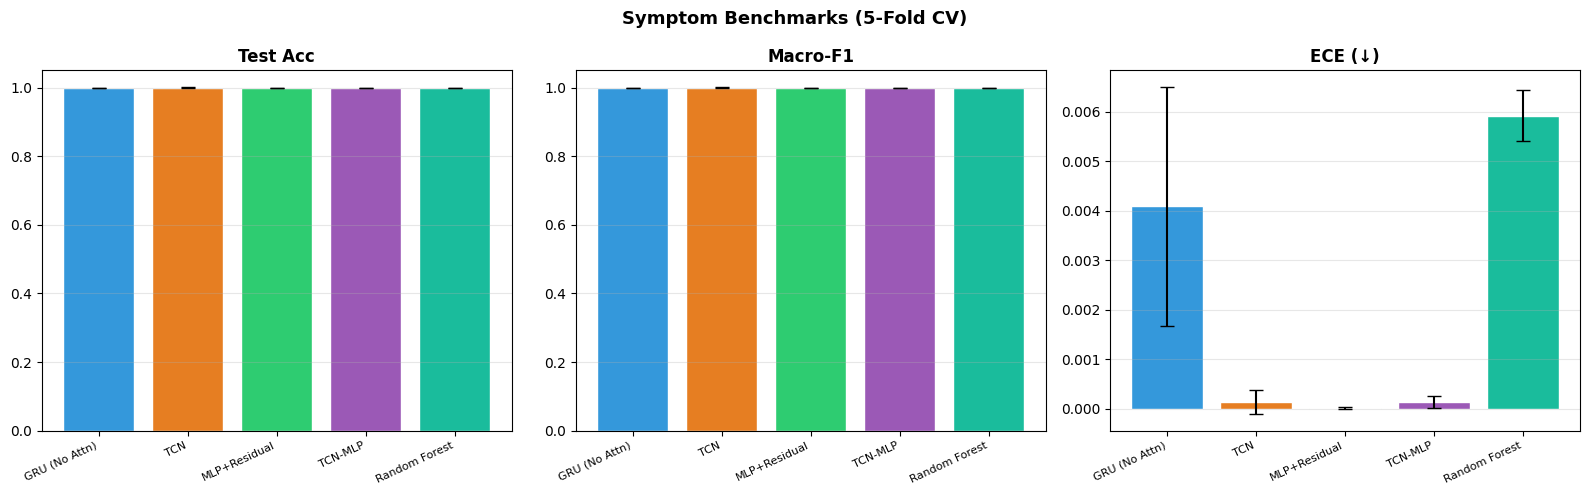


✅ Symptom benchmarks complete!


In [1]:
# NB3: SYMPTOM BENCHMARKS — GRU, TCN, MLP, TCN-MLP, RF (R1-P3)
# No SMOTE (data pre-balanced). No model saving (values only).
# Run on Colab GPU (~2-3 hrs)
import numpy as np,pandas as pd,matplotlib.pyplot as plt,os
from keras.models import Model
from keras.layers import (Input,Dense,Dropout,Conv1D,Flatten,GRU,
                          Bidirectional,concatenate,BatchNormalization,Activation,Add)
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from keras.utils import to_categorical
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import f1_score,recall_score,top_k_accuracy_score
from sklearn.ensemble import RandomForestClassifier
import warnings;warnings.filterwarnings('ignore')
os.makedirs('/content/results',exist_ok=True);os.makedirs('/content/figures',exist_ok=True)
def ece_fn(yt,yp,n=10):
    c=np.max(yp,1);p=np.argmax(yp,1);a=(p==yt).astype(float);e=0.0
    for i in range(n):
        bl,bu=i/n,(i+1)/n;m=(c>=bl)&(c<=bu) if i==n-1 else (c>=bl)&(c<bu)
        pp=np.mean(m)
        if pp>0:e+=np.abs(np.mean(c[m])-np.mean(a[m]))*pp
    return e
def brier(yo,yp):return np.mean(np.sum((yp-yo)**2,1))
dataset=pd.read_csv('/content/symbipredict_2022.csv')
X_all=dataset.drop('prognosis',axis=1).values
le=LabelEncoder();y_all=le.fit_transform(dataset['prognosis'].values)
nc=len(le.classes_);nd=X_all.shape[1]
X_tv,X_te,y_tv,y_te=train_test_split(X_all,y_all,test_size=0.3,stratify=y_all,random_state=42)
acute_labels=['Heart Attack','Pneumonia','Tuberculosis','Typhoid','Hepatitis E',
'Dengue','Malaria','Jaundice','Paralysis (brain hemorrhage)',
'Alcoholic Hepatitis','Drug Reaction','Gastroenteritis']
acute_idx=[np.where(le.classes_==l)[0][0] for l in acute_labels if l in le.classes_]
L2=1e-3
def build_gru():
    i=Input(shape=(nd,1));x=Bidirectional(GRU(128,return_sequences=False,kernel_regularizer=l2(L2)))(i)
    x=Dense(128,activation='relu',kernel_regularizer=l2(L2))(x);x=Dropout(0.5)(x)
    o=Dense(nc,activation='softmax')(x);m=Model(i,o)
    m.compile(optimizer=Adam(1e-3), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')])
    return m
def build_tcn():
    def B(x,f,d):
        s=x;x=Conv1D(f,3,padding='causal',dilation_rate=d,kernel_regularizer=l2(L2))(x)
        x=BatchNormalization()(x);x=Activation('relu')(x);x=Dropout(0.3)(x)
        x=Conv1D(f,3,padding='causal',dilation_rate=d,kernel_regularizer=l2(L2))(x)
        x=BatchNormalization()(x);s=Conv1D(f,1,padding='same')(s);return Add()([s,x])
    i=Input(shape=(nd,1));x=B(i,64,1);x=B(x,64,2);x=Flatten()(x)
    x=Dense(128,activation='relu',kernel_regularizer=l2(L2))(x);x=Dropout(0.5)(x)
    o=Dense(nc,activation='softmax')(x);m=Model(i,o)
    m.compile(optimizer=Adam(1e-3), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')])
    return m
def build_mlp():
    def R(x,u):
        s=x;x=Dense(u,kernel_regularizer=l2(L2))(x);x=BatchNormalization()(x);x=Activation('relu')(x)
        x=Dense(u,kernel_regularizer=l2(L2))(x);x=BatchNormalization()(x);return Activation('relu')(Add()([s,x]))
    i=Input(shape=(nd,));x=Dense(256,activation='relu',kernel_regularizer=l2(L2))(i)
    x=R(x,256);x=Dropout(0.5)(x);x=R(x,256);x=Dropout(0.5)(x)
    o=Dense(nc,activation='softmax')(x);m=Model(i,o)
    m.compile(optimizer=Adam(1e-3), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')])
    return m
def build_tcn_mlp():
    ti=Input(shape=(nd,1));x1=Conv1D(64,3,padding='causal',dilation_rate=1,kernel_regularizer=l2(L2))(ti)
    x1=BatchNormalization()(x1);x1=Activation('relu')(x1);x1=Dropout(0.3)(x1)
    x1=Conv1D(64,3,padding='causal',dilation_rate=2,kernel_regularizer=l2(L2))(x1)
    x1=BatchNormalization()(x1);x1=Flatten()(x1)
    mi=Input(shape=(nd,));x2=Dense(128,activation='relu',kernel_regularizer=l2(L2))(mi)
    x2=BatchNormalization()(x2);x2=Dropout(0.5)(x2);x2=Dense(128,activation='relu',kernel_regularizer=l2(L2))(x2)
    mg=concatenate([x1,x2]);x=Dense(256,activation='relu',kernel_regularizer=l2(L2))(mg);x=Dropout(0.5)(x)
    o=Dense(nc,activation='softmax')(x);m=Model([ti,mi],o)
    m.compile(optimizer=Adam(1e-3), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy(name='accuracy')])
    return m
def run(name,builder,dl=True,dual=False,flat=False):
    print(f"\n{'='*55}\n {name}\n{'='*55}")
    skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42);res=[]
    for fold,(ti,vi) in enumerate(skf.split(X_tv,y_tv)):
        Xtr,Xvl=X_tv[ti],X_tv[vi];ytr,yvl=y_tv[ti],y_tv[vi]
        sc=StandardScaler();Xtr=sc.fit_transform(Xtr);Xvl=sc.transform(Xvl);Xtest=sc.transform(X_te)
        # NO SMOTE — data already balanced
        yte_o=to_categorical(y_te,nc)
        if dl:
            ytr_o=to_categorical(ytr,nc);yvl_o=to_categorical(yvl,nc)
            mdl=builder()
            cbs=[EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=5,min_lr=1e-7)]
            if dual:
                mdl.fit([np.expand_dims(Xtr,-1),Xtr],ytr_o,validation_data=([np.expand_dims(Xvl,-1),Xvl],yvl_o),
                        epochs=50,batch_size=32,callbacks=cbs,verbose=0)
                tl,ta=mdl.evaluate([np.expand_dims(Xtest,-1),Xtest],yte_o,verbose=0)
                yp=mdl.predict([np.expand_dims(Xtest,-1),Xtest],verbose=0)
            elif flat:
                mdl.fit(Xtr,ytr_o,validation_data=(Xvl,yvl_o),epochs=50,batch_size=32,callbacks=cbs,verbose=0)
                tl,ta=mdl.evaluate(Xtest,yte_o,verbose=0);yp=mdl.predict(Xtest,verbose=0)
            else:
                mdl.fit(np.expand_dims(Xtr,-1),ytr_o,validation_data=(np.expand_dims(Xvl,-1),yvl_o),
                        epochs=50,batch_size=32,callbacks=cbs,verbose=0)
                tl,ta=mdl.evaluate(np.expand_dims(Xtest,-1),yte_o,verbose=0)
                yp=mdl.predict(np.expand_dims(Xtest,-1),verbose=0)
        else:
            mdl=builder();mdl.fit(Xtr,ytr);ta=mdl.score(Xtest,y_te)
            yp=mdl.predict_proba(Xtest);tl=-np.mean(np.sum(yte_o*np.log(yp+1e-10),1))
        ypc=np.argmax(yp,1);f1=f1_score(y_te,ypc,average='macro')
        t3=top_k_accuracy_score(y_te,yp,k=3);t5=top_k_accuracy_score(y_te,yp,k=5)
        ec=ece_fn(y_te,yp);br=brier(yte_o,yp)
        se=recall_score(y_te,ypc,labels=acute_idx,average='macro',zero_division=0)
        print(f" F{fold+1}: Acc={ta:.4f} F1={f1:.4f} ECE={ec:.5f}")
        res.append({'test_acc':ta,'test_loss':tl,'macro_f1':f1,'top3':t3,'top5':t5,'ece':ec,'brier':br,'sens_acute':se})
    print(f"\n Summary:")
    for k in res[0]:vs=[r[k] for r in res];print(f" {k:<15}: {np.mean(vs):.4f} ± {np.std(vs,ddof=1):.4f}")
    return res
ALL={}
ALL['GRU (No Attn)']=run('GRU (No Attention)',build_gru)
ALL['TCN']=run('TCN',build_tcn)
ALL['MLP+Residual']=run('MLP + Residual',build_mlp,flat=True)
ALL['TCN-MLP']=run('TCN-MLP Hybrid',build_tcn_mlp,dual=True)
ALL['Random Forest']=run('Random Forest',lambda:RandomForestClassifier(n_estimators=100,random_state=42),dl=False)
print(f"\n{'='*80}\n SYMPTOM BENCHMARKS TABLE\n{'='*80}")
rows=[]
for nm,res in ALL.items():
    row={'Model':nm}
    for k in res[0]:vs=[r[k] for r in res];row[k]=f"{np.mean(vs):.4f} ± {np.std(vs,ddof=1):.4f}"
    rows.append(row)
df=pd.DataFrame(rows).set_index('Model');print(df.to_string())
df.to_csv('/content/results/symptom_benchmarks.csv')
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,mk,tt in zip(axes,['test_acc','macro_f1','ece'],['Test Acc','Macro-F1','ECE (↓)']):
    nms=list(ALL.keys());ms=[np.mean([r[mk] for r in ALL[n]]) for n in nms]
    ss=[np.std([r[mk] for r in ALL[n]],ddof=1) for n in nms]
    cs=['#3498DB','#E67E22','#2ECC71','#9B59B6','#1ABC9C']
    ax.bar(range(len(nms)),ms,yerr=ss,color=cs,capsize=5,edgecolor='white')
    ax.set_xticks(range(len(nms)));ax.set_xticklabels(nms,rotation=25,ha='right',fontsize=8)
    ax.set_title(tt,fontweight='bold');ax.grid(alpha=0.3,axis='y')
plt.suptitle('Symptom Benchmarks (5-Fold CV)',fontsize=13,fontweight='bold')
plt.tight_layout();plt.savefig('/content/figures/symptom_benchmarks.png',dpi=300,bbox_inches='tight');plt.show()
print("\n✅ Symptom benchmarks complete!")